# Machine Learning: Predicción de Ventas de Videojuegos
## Proyecto en Clase - NexaPlay Studios
**Seminario de Titulación - Analítica con Python**  
**Universidad de los Andes (UniAndes) · 2026**  
**Sesión: Viernes 9 de mayo, 2026**

---

### Objetivo de esta sesión

En esta sesión vamos a construir, evaluar y exportar un modelo de Machine Learning (ML) que prediga las ventas globales de un videojuego antes de que sea lanzado al mercado.  

Al finalizar el notebook tendremos dos archivos listos para producción:
- `catboost_regressor.joblib` - el modelo entrenado
- `onehot_encoder.joblib` - el preprocesador de variables categóricas

Estos dos archivos serán la base de la API que construiremos en la siguiente sesión.

---
## 1. Introducción y contexto del problema

### ¿Qué es Machine Learning?

Machine Learning (ML) es una rama de la inteligencia artificial que permite a un programa **aprender patrones a partir de datos históricos** y usarlos para hacer predicciones sobre datos nuevos.  

La idea central es simple: en lugar de escribir reglas manualmente ("si el critic_score es mayor a 80 entonces las ventas serán altas"), le damos al modelo miles de ejemplos pasados y él encuentra las reglas por sí solo.

### El caso NexaPlay

NexaPlay Studios está a punto de lanzar su primer videojuego. Antes del lanzamiento conocen:
- La plataforma en la que saldrá
- El género del juego
- La clasificación ESRB
- Las reseñas anticipadas de críticos especializados
- El año de lanzamiento planeado

La pregunta de negocio es: **¿cuántas unidades (en millones) podría vender este juego?**

Eso es exactamente lo que nuestro modelo va a intentar responder.

### ¿Qué tipo de problema de ML es este?

Existen dos grandes familias de problemas supervisados en ML:

| Tipo | ¿Qué predice? | Ejemplo |
|---|---|---|
| **Clasificación** | Una categoría o clase | ¿Este juego será exitoso (sí/no)? |
| **Regresión** | Un valor numérico continuo | ¿Cuántas millones de copias venderá? |

Nuestro target (`total_sales`) es un número continuo, así que estamos ante un **problema de regresión**.

### Limitación importante antes de empezar

Los modelos de ML no son oráculos. En industrias con alta variabilidad como los videojuegos, factores como el marketing, las tendencias virales o el boca a boca son imposibles de capturar con datos históricos. Nuestro modelo nos dará una estimación basada en patrones del pasado, no una predicción perfecta. Eso es completamente válido y útil para tomar decisiones.

---
## 2. Carga del dataset

### 2.1 Librerías

Antes de cargar los datos, importamos todas las librerías que vamos a usar en este notebook.  
Es una buena práctica tenerlas todas al inicio para saber exactamente de qué depende el proyecto.

In [6]:
# librerías generales
import pandas as pd
import numpy as np
import joblib
import os

# visualización
import matplotlib.pyplot as plt
import seaborn as sns

# preprocesamiento
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# métricas de evaluación
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# modelos
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


### 2.2 Cargar el dataset

Nuestro punto de partida es `games_clean.csv`, el dataset ya limpio e imputado que fue procesado en etapas anteriores del proyecto. No volvemos al dato crudo: la limpieza ya está hecha.

In [7]:
# construir ruta relativa al archivo
BASE_DIR  = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, 'data', 'games_clean.csv')

# cargar el dataset
df = pd.read_csv(DATA_PATH)

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 8,296 filas x 14 columnas


,videogame_names,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating_esrb,total_sales,gen_platform,classification_user_score
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,7ª Gen,Good
1,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,7ª Gen,Good
2,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,7ª Gen,Good
3,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80,7ª Gen,Excellent
4,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91,7ª Gen,Regular


In [8]:
# revisión rápida de tipos y nulos
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 8296 entries, 0 to 8295
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   videogame_names            8296 non-null   str    
 1   platform                   8296 non-null   str    
 2   year_of_release            8296 non-null   int64  
 3   genre                      8296 non-null   str    
 4   na_sales                   8296 non-null   float64
 5   eu_sales                   8296 non-null   float64
 6   jp_sales                   8296 non-null   float64
 7   other_sales                8296 non-null   float64
 8   critic_score               8296 non-null   float64
 9   user_score                 8296 non-null   float64
 10  rating_esrb                8296 non-null   str    
 11  total_sales                8296 non-null   float64
 12  gen_platform               8296 non-null   str    
 13  classification_user_score  8296 non-null   str    
dtypes: 

---
## 3. Análisis exploratorio orientado al modelado

El análisis exploratorio completo del dataset ya lo hicimos en el dashboard. Aquí hacemos tres revisiones puntuales que son necesarias antes de entrenar: cómo se distribuye el target, qué relación tienen las variables numéricas con las ventas, y cuántos registros hay en cada categoría.

### 3.1 Distribución del target

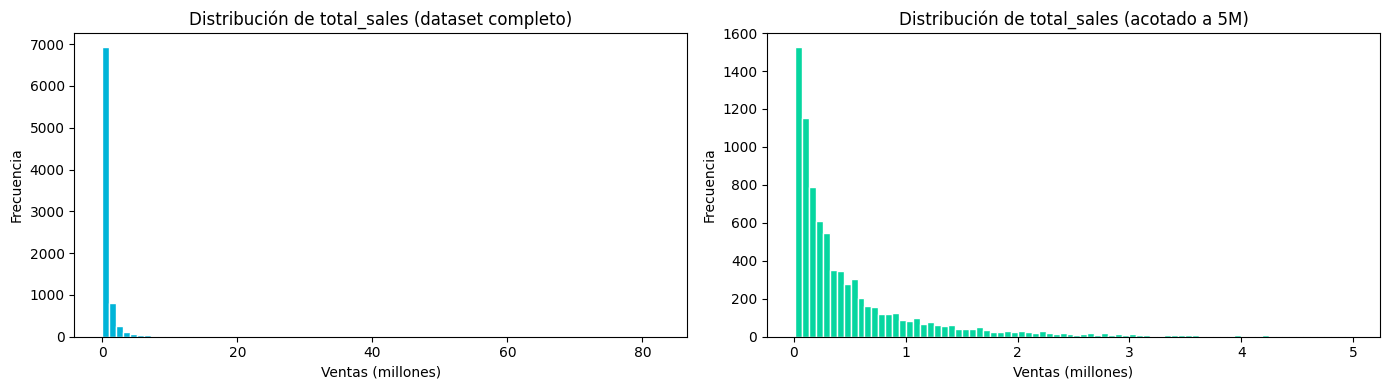

Skewness: 17.07
Media:    0.71M
Mediana:  0.26M
Máximo:   82.54M
% juegos con ventas < 1M: 82.7%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# histograma del target completo
axes[0].hist(df['total_sales'], bins=80, color='#00B4D8', edgecolor='white')
axes[0].set_title('Distribución de total_sales (dataset completo)')
axes[0].set_xlabel('Ventas (millones)')
axes[0].set_ylabel('Frecuencia')

# histograma acotado para ver la masa de datos
axes[1].hist(df[df['total_sales'] <= 5]['total_sales'], bins=80, color='#06D6A0', edgecolor='white')
axes[1].set_title('Distribución de total_sales (acotado a 5M)')
axes[1].set_xlabel('Ventas (millones)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f'Skewness: {df["total_sales"].skew():.2f}')
print(f'Media:    {df["total_sales"].mean():.2f}M')
print(f'Mediana:  {df["total_sales"].median():.2f}M')
print(f'Máximo:   {df["total_sales"].max():.2f}M')
print(f'% juegos con ventas < 1M: {(df["total_sales"] < 1).mean()*100:.1f}%')

### 3.2 Correlación de variables numéricas con total_sales

In [10]:
correlaciones = df[['critic_score', 'user_score', 'year_of_release', 'total_sales']]\
    .corr()['total_sales'].drop('total_sales').sort_values(ascending=False)

print('Correlación con total_sales:')
print(correlaciones)

Correlación con total_sales:
critic_score       0.233046
user_score         0.089952
year_of_release   -0.013212
Name: total_sales, dtype: float64


### 3.3 Conteo de variables categóricas

In [11]:
for col in ['genre', 'platform', 'rating_esrb', 'gen_platform', 'classification_user_score']:
    print(f'--- {col} ({df[col].nunique()} valores únicos) ---')
    print(df[col].value_counts().to_string())
    print()

--- genre (12 valores únicos) ---
genre
Action          2031
Sports          1267
Shooter          948
Role-Playing     788
Racing           718
Misc             511
Platform         510
Fighting         439
Simulation       329
Adventure        322
Strategy         298
Puzzle           135

--- platform (24 valores únicos) ---
platform
PS2     1305
X360     969
PS3      924
PC       735
XB       680
DS       608
Wii      601
PSP      488
GC       445
GBA      345
PS4      283
XOne     201
3DS      191
PS       179
PSV      165
WiiU     110
DC        16
N64       15
SNES      14
SAT        9
GB         4
GEN        3
NES        3
2600       3

--- rating_esrb (7 valores únicos) ---
rating_esrb
T       2644
E       2578
M       1507
E10+    1173
RP       392
AO         1
K-A        1

--- gen_platform (8 valores únicos) ---
gen_platform
7ª Gen         3590
6ª Gen         2775
8ª Gen          950
PC              735
5ª Gen          203
4ª Gen           21
Otras/Retro      16
3ª Gen      

---
## 4. Definición del problema de ML

### 4.1 ¿Qué queremos predecir? (variable target)

La **variable target** (o variable dependiente) es lo que el modelo va a aprender a predecir. En nuestro caso es `total_sales`: las ventas globales en millones de unidades.

### 4.2 ¿Qué variables podemos usar como features?

Las **features** (o variables independientes) son la información que le damos al modelo para que haga su predicción. Aquí hay una regla fundamental que no se puede romper:

> **Solo podemos usar información que estaría disponible ANTES del lanzamiento del juego.**

El dataset tiene las columnas `na_sales`, `eu_sales`, `jp_sales` y `other_sales`. A primera vista parecen útiles, pero hay un problema crítico: `total_sales` es exactamente la suma de esas cuatro columnas. Si las usamos como features, le estamos diciendo al modelo 'predice la suma conociendo todos los sumandos'. El modelo obtendrá un desempeño artificialmente perfecto, pero será completamente inútil en producción porque esas ventas regionales tampoco existen antes del lanzamiento. Este error se llama **data leakage** (filtración de datos) y es uno de los errores más comunes en ML.

Las features válidas para nuestro modelo son:

| Variable | Tipo | Justificación |
|---|---|---|
| `platform` | Categórica | Se conoce antes del lanzamiento |
| `genre` | Categórica | Se conoce antes del lanzamiento |
| `rating_esrb` | Categórica | Se conoce antes del lanzamiento |
| `gen_platform` | Categórica | Derivada de platform |
| `classification_user_score` | Categórica | Reseñas anticipadas de usuarios |
| `year_of_release` | Numérica | Año de lanzamiento planeado |
| `critic_score` | Numérica | Reseñas anticipadas de críticos |
| `user_score` | Numérica | Puntuación de usuarios antes del lanzamiento |

In [ ]:
# definir las columnas que usaremos
COLUMNAS_CATEGORICAS = ['platform', 'genre', 'rating_esrb', 'gen_platform', 'classification_user_score']
COLUMNAS_NUMERICAS   = ['year_of_release', 'critic_score', 'user_score']
TARGET               = 'total_sales'

print('Features categóricas:', COLUMNAS_CATEGORICAS)
print('Features numéricas:  ', COLUMNAS_NUMERICAS)
print('Target:              ', TARGET)

Features categóricas: ['platform', 'genre', 'rating_esrb', 'gen_platform', 'classification_user_score']
Features numéricas:   ['year_of_release', 'critic_score', 'user_score']
Target:               total_sales


---
## 5. Análisis y tratamiento del target

### 5.1 El problema del skewness

**Skewness** (o asimetría) mide qué tan sesgada está la distribución de una variable. Una distribución perfectamente simétrica tiene skewness = 0. Cuando el skewness es muy alto, significa que hay valores extremos en la cola derecha (en este caso, juegos que vendieron decenas de millones de copias) que arrastran la media hacia arriba y dominan el error del modelo.

El dataset completo tiene un skewness de **17.07**, que es extremadamente alto. Para que tengas referencia, una distribución normal tiene skewness cercano a 0, y ya con valores mayores a 2 o 3 empieza a ser problemático para muchos modelos.

### 5.2 Decisión: eliminar el top 5% de ventas

Una estrategia común para manejar distribuciones muy sesgadas es eliminar los outliers del extremo superior antes de entrenar. Estos son juegos como Wii Sports (82.54M) o Grand Theft Auto V, cuyo éxito depende de factores únicos e irrepetibles que ningún modelo puede capturar con estas variables.

**Punto importante:** esto NO modifica el archivo `games_clean.csv` en disco. Creamos una variable temporal `df_modelo` que existe solo durante esta sesión de entrenamiento. El CSV original se mantiene intacto porque el dashboard y otros análisis necesitan ver todos los datos, incluidos esos blockbusters. La eliminación de outliers es una decisión de **modelado**, no una decisión de **limpieza de datos**.

La limitación que esto implica es explícita: el modelo aprenderá a predecir bien en el rango de 0 a ~2.64M de ventas. Para juegos con potencial de blockbuster, la predicción será menos confiable.

In [13]:
# calcular el corte en el percentil 95
PERCENTIL_CORTE = 95
techo_ventas = df[TARGET].quantile(PERCENTIL_CORTE / 100)

print(f'Corte en percentil {PERCENTIL_CORTE}: {techo_ventas:.2f}M de ventas')
print(f'Filas en dataset completo:      {len(df):,}')

# crear el dataframe de entrenamiento sin los outliers del top 5%
# este dataframe es temporal, el games_clean.csv original no se modifica
df_modelo = df[df[TARGET] <= techo_ventas].copy().reset_index(drop=True)

print(f'Filas en df_modelo (sin top 5%): {len(df_modelo):,}')
print(f'Filas eliminadas:                {len(df) - len(df_modelo):,} ({(len(df)-len(df_modelo))/len(df)*100:.1f}%)')

Corte en percentil 95: 2.64M de ventas
Filas en dataset completo:      8,296
Filas en df_modelo (sin top 5%): 7,882
Filas eliminadas:                414 (5.0%)


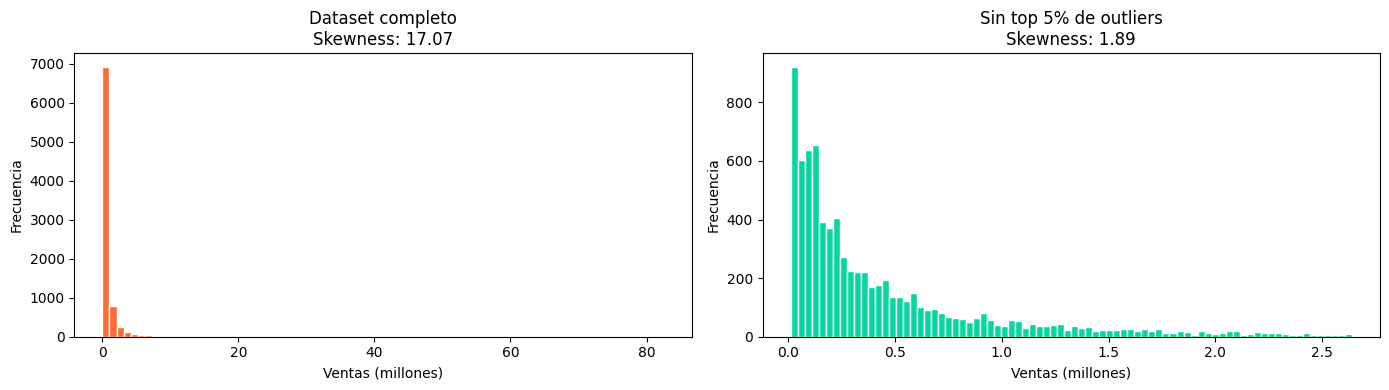

In [14]:
# comparar la distribución antes y después
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[TARGET], bins=80, color='#FF6B35', edgecolor='white')
axes[0].set_title(f'Dataset completo\nSkewness: {df[TARGET].skew():.2f}')
axes[0].set_xlabel('Ventas (millones)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_modelo[TARGET], bins=80, color='#06D6A0', edgecolor='white')
axes[1].set_title(f'Sin top 5% de outliers\nSkewness: {df_modelo[TARGET].skew():.2f}')
axes[1].set_xlabel('Ventas (millones)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

---
## 6. Preprocesamiento

### 6.1 Separar features y target

El primer paso es separar el dataset en dos partes:
- **X**: todas las features (lo que el modelo recibe como entrada)
- **y**: el target (lo que el modelo debe predecir)

Esta separación es una convención universal en ML. La letra X se usa en mayúscula porque es una matriz (muchas columnas), y la letra y en minúscula porque es un vector (una sola columna).

In [15]:
# separar features y target
X_categoricas = df_modelo[COLUMNAS_CATEGORICAS]
X_numericas   = df_modelo[COLUMNAS_NUMERICAS]
y             = df_modelo[TARGET]

print('Shape X_categoricas:', X_categoricas.shape)
print('Shape X_numericas:  ', X_numericas.shape)
print('Shape y:            ', y.shape)

Shape X_categoricas: (7882, 5)
Shape X_numericas:   (7882, 3)
Shape y:             (7882,)


### 6.2 OneHotEncoding: convertir categorías a números

Los modelos de ML trabajan exclusivamente con números. Las columnas como `genre` o `platform` contienen texto, así que hay que transformarlas.

**OneHotEncoding** convierte cada categoría en una columna binaria (0 o 1). Por ejemplo, la columna `genre` con 12 géneros se convierte en 12 columnas: `genre_Action`, `genre_Sports`, `genre_Racing`, etc. Para un juego de acción, `genre_Action = 1` y el resto son 0.

El parámetro `handle_unknown='ignore'` le dice al encoder que si en producción llega una categoría que no vio durante el entrenamiento, la ignore en lugar de generar un error. Es una medida de robustez para cuando el modelo esté en la API.

In [16]:
# crear y entrenar el encoder
# fit_transform: aprende las categorías existentes (fit) y las transforma (transform) en un solo paso
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_encoded = encoder.fit_transform(X_categoricas)

# obtener los nombres de las nuevas columnas generadas
nombres_columnas_ohe = encoder.get_feature_names_out(COLUMNAS_CATEGORICAS)

# convertir el resultado a DataFrame para poder concatenarlo
X_cat_df = pd.DataFrame(X_cat_encoded, columns=nombres_columnas_ohe)

print(f'Columnas antes del OHE: {len(COLUMNAS_CATEGORICAS)}')
print(f'Columnas después del OHE: {X_cat_df.shape[1]}')
print('Primeras 5 columnas generadas:', list(nombres_columnas_ohe[:5]))

Columnas antes del OHE: 5
Columnas después del OHE: 55
Primeras 5 columnas generadas: ['platform_2600', 'platform_3DS', 'platform_DC', 'platform_DS', 'platform_GB']


In [17]:
# concatenar las variables numéricas con las categóricas codificadas
# reset_index(drop=True): asegura que los índices estén alineados antes de concatenar
X = pd.concat([X_numericas.reset_index(drop=True), X_cat_df], axis=1)

print(f'Shape final de X: {X.shape}  ({X.shape[1]} columnas en total)')
X.head()

Shape final de X: (7882, 58)  (58 columnas en total)


,year_of_release,critic_score,user_score,platform_2600,platform_3DS,platform_DC,platform_DS,platform_GB,platform_GBA,platform_GC,...,gen_platform_5ª Gen,gen_platform_6ª Gen,gen_platform_7ª Gen,gen_platform_8ª Gen,gen_platform_Otras/Retro,gen_platform_PC,classification_user_score_Bad,classification_user_score_Excellent,classification_user_score_Good,classification_user_score_Regular
0,2006,71.0,7.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2011,79.0,6.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2000,78.0,7.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2010,80.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2004,90.0,8.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 6.3 Train/Test Split, overfitting y random_state

**¿Por qué dividir los datos?**

Imagina que estudias para un examen usando exactamente las mismas preguntas que van a aparecer. Obtendrías un 100, pero no porque aprendiste, sino porque memorizaste. Eso es exactamente lo que hace un modelo si lo evaluamos con los mismos datos con los que entrenó. Este fenómeno se llama **overfitting** (sobreajuste).

Para detectarlo, dividimos el dataset en dos subconjuntos:
- **X_train / y_train (75%)**: los datos con los que el modelo aprende
- **X_test / y_test (25%)**: los datos que el modelo nunca vio, usados solo para evaluarlo

Si el modelo tiene buen desempeño en el test, realmente generalizó. Si solo funciona bien en el train, está memorizando.

**¿Qué es `random_state`?**

`train_test_split` divide los datos de forma aleatoria. `random_state=50` fija una semilla aleatoria para que la división sea siempre la misma cada vez que se corre el notebook. Esto garantiza **reproducibilidad**: si otro estudiante corre este código con el mismo dataset, obtendrá exactamente los mismos resultados.

In [18]:
RANDOM_STATE = 50
TEST_SIZE    = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f'X_train: {X_train.shape}  ({TEST_SIZE*100:.0f}% para test, {(1-TEST_SIZE)*100:.0f}% para entrenamiento)')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (5911, 58)  (25% para test, 75% para entrenamiento)
X_test:  (1971, 58)
y_train: (5911,)
y_test:  (1971,)


---
## 7. Entrenamiento y comparación de modelos

### 7.0 Conceptos previos al entrenamiento

#### ¿Qué hacen `.fit()` y `.predict()`?

Todos los modelos de scikit-learn y sus equivalentes siguen la misma interfaz:
- **`.fit(X_train, y_train)`**: entrena el modelo. El modelo ajusta sus parámetros internos para minimizar el error en los datos de entrenamiento. Solo se llama una vez.
- **`.predict(X_test)`**: usa el modelo ya entrenado para generar predicciones sobre datos nuevos. Solo recibe X, porque y es exactamente lo que estamos tratando de predecir.

#### ¿Qué son los hiperparámetros?

Los modelos tienen dos tipos de valores numéricos:
- **Parámetros**: los aprende el modelo solo durante el entrenamiento (pesos internos, coeficientes).
- **Hiperparámetros**: los define el programador antes de entrenar. Por ejemplo `random_state=50`, `n_estimators=100` (cuántos árboles usar), `n_jobs=-1` (usar todos los núcleos del procesador para ir más rápido).

En esta sesión usamos los hiperparámetros por defecto de cada modelo. Ajustarlos para mejorar el desempeño (proceso llamado **tuning**) es un paso avanzado que no cubriremos aquí.

#### Métricas de evaluación para regresión

Una vez que el modelo predice, necesitamos medir qué tan lejos estuvieron sus predicciones de los valores reales. Usamos tres métricas complementarias:

| Métrica | Fórmula | ¿Qué mide? | ¿Cómo interpretarla? |
|---|---|---|---|
| **RMSE** | √(media de errores²) | Error promedio penalizando los errores grandes | Mismas unidades que el target (millones). Menor es mejor. |
| **MAE** | media de \|errores\| | Error absoluto promedio sin penalizar outliers | Más robusto que RMSE. Menor es mejor. |
| **R²** | 1 - SS_res/SS_tot | Proporción de la varianza explicada por el modelo | Va de 0 a 1. Más cercano a 1 es mejor. |

**¿Cuándo usar cada una?**
- Si los outliers importan mucho (un error grande es muy costoso), usa RMSE porque los penaliza más.
- Si quieres saber el error típico en el día a día sin que los casos extremos distorsionen, usa MAE.
- Si quieres saber qué tan bien el modelo explica la variabilidad del fenómeno, usa R².

Un R² de 0.26 significa que el modelo explica el 26% de la variabilidad en las ventas. Puede sonar bajo, pero en un dominio tan impredecible como la industria del videojuego, cualquier señal estadística tiene valor para tomar decisiones.

### 7.1 Modelo 1: Ridge Regression

**¿Qué es?** Ridge es una regresión lineal con regularización. Busca la mejor línea recta (o hiperplano en múltiples dimensiones) que relacione las features con el target. El término de regularización evita que los coeficientes crezcan demasiado, lo que reduce el overfitting en modelos lineales.

**¿Cuándo funciona bien?** Cuando la relación entre las variables y el target es aproximadamente lineal.

**¿Por qué lo incluimos?** Lo usamos como **baseline**: el piso de referencia. Si un modelo complejo no supera significativamente a Ridge, algo está mal en ese modelo.

In [19]:
modelo_ridge = Ridge()

# fit: el modelo aprende los coeficientes que minimizan el error
modelo_ridge.fit(X_train, y_train)

# predict: el modelo genera predicciones sobre datos que nunca vio
pred_ridge = modelo_ridge.predict(X_test)

rmse_ridge = root_mean_squared_error(y_test, pred_ridge)
mae_ridge  = mean_absolute_error(y_test, pred_ridge)
r2_ridge   = r2_score(y_test, pred_ridge)

print('Ridge Regression')
print(f'  RMSE: {rmse_ridge:.4f}')
print(f'  MAE:  {mae_ridge:.4f}')
print(f'  R2:   {r2_ridge:.4f}')

Ridge Regression
  RMSE: 0.4525
  MAE:  0.3228
  R2:   0.2082


### 7.2 Modelo 2: Random Forest

**¿Qué es?** Random Forest es un modelo de ensamble basado en árboles de decisión. Entrena cientos de árboles de forma independiente, cada uno con una muestra aleatoria de los datos y una selección aleatoria de features. La predicción final es el promedio de todos los árboles.

La intuición detrás: así como un comité de expertos toma mejores decisiones que un solo experto, muchos árboles simples juntos superan a un solo árbol complejo.

**Ventaja sobre Ridge:** captura relaciones no lineales entre las variables y el target, que es exactamente lo que ocurre en nuestros datos de ventas.

**Hiperparámetro clave:** `n_estimators=100` define cuántos árboles construir. Más árboles generalmente dan mejor resultado, pero aumentan el tiempo de entrenamiento.

In [20]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,   # número de árboles en el bosque
    random_state=RANDOM_STATE,
    n_jobs=-1           # usa todos los núcleos del procesador
)

modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

rmse_rf = root_mean_squared_error(y_test, pred_rf)
mae_rf  = mean_absolute_error(y_test, pred_rf)
r2_rf   = r2_score(y_test, pred_rf)

print('Random Forest')
print(f'  RMSE: {rmse_rf:.4f}')
print(f'  MAE:  {mae_rf:.4f}')
print(f'  R2:   {r2_rf:.4f}')

Random Forest
  RMSE: 0.4494
  MAE:  0.3074
  R2:   0.2188


### 7.3 Modelo 3: XGBoost

**¿Qué es?** XGBoost (Extreme Gradient Boosting) es un modelo de **gradient boosting**. A diferencia de Random Forest que construye árboles en paralelo de forma independiente, el boosting construye árboles de forma **secuencial**: cada árbol nuevo aprende de los errores del árbol anterior, corrigiéndolos progresivamente.

La analogía: en lugar de un comité de expertos independientes (Random Forest), es un equipo donde cada persona corrige los errores del anterior.

**¿Por qué XGBoost es popular?** Ganó decenas de competencias de ML en Kaggle entre 2014 y 2017 y se convirtió en el modelo de referencia para datos tabulares.

**Referencia:** Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD*, 785-794.

In [21]:
modelo_xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0     # silencia los logs del entrenamiento
)

modelo_xgb.fit(X_train, y_train)
pred_xgb = modelo_xgb.predict(X_test)

rmse_xgb = root_mean_squared_error(y_test, pred_xgb)
mae_xgb  = mean_absolute_error(y_test, pred_xgb)
r2_xgb   = r2_score(y_test, pred_xgb)

print('XGBoost')
print(f'  RMSE: {rmse_xgb:.4f}')
print(f'  MAE:  {mae_xgb:.4f}')
print(f'  R2:   {r2_xgb:.4f}')

XGBoost
  RMSE: 0.4581
  MAE:  0.3118
  R2:   0.1885


### 7.4 Modelo 4: LightGBM

**¿Qué es?** LightGBM (Light Gradient Boosting Machine) es otra implementación de gradient boosting, desarrollada por Microsoft. Su principal diferencia respecto a XGBoost es la estrategia de crecimiento de los árboles: XGBoost crece nivel por nivel (level-wise), mientras que LightGBM crece hoja por hoja (leaf-wise), lo que lo hace más rápido y generalmente más preciso en datasets medianos.

**Cuándo conviene sobre XGBoost:** en datasets con muchas columnas (como el nuestro con 58 features después del OHE) y tamaño mediano (miles a cientos de miles de filas), LightGBM suele ser más rápido y obtener mejores métricas.

**Referencia:** Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T. Y. (2017). LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems*, 30.

In [22]:
modelo_lgbm = LGBMRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1      # silencia los logs del entrenamiento
)

modelo_lgbm.fit(X_train, y_train)
pred_lgbm = modelo_lgbm.predict(X_test)

rmse_lgbm = root_mean_squared_error(y_test, pred_lgbm)
mae_lgbm  = mean_absolute_error(y_test, pred_lgbm)
r2_lgbm   = r2_score(y_test, pred_lgbm)

print('LightGBM')
print(f'  RMSE: {rmse_lgbm:.4f}')
print(f'  MAE:  {mae_lgbm:.4f}')
print(f'  R2:   {r2_lgbm:.4f}')

LightGBM
  RMSE: 0.4401
  MAE:  0.2982
  R2:   0.2510


### 7.5 Modelo 5: CatBoost

**¿Qué es?** CatBoost (Categorical Boosting) es una implementación de gradient boosting desarrollada por Yandex. Su diferenciador principal es el manejo de variables categóricas: mientras XGBoost y LightGBM requieren que el usuario aplique OHE u otro encoding antes de entrenar, CatBoost puede trabajar con las categorías directamente usando una técnica interna llamada ordered target statistics.

En nuestro caso aplicamos OHE de todas formas para mantener consistencia con los otros modelos y porque necesitamos el encoder para la API. Pero CatBoost suele capturar mejor las interacciones entre variables categóricas, lo que lo hace competitivo en este tipo de datasets.

**Referencia:** Prokhorenkova, L., Gusev, G., Vorobev, A., Dorogush, A. V., & Gulin, A. (2018). CatBoost: Unbiased boosting with categorical features. *Advances in Neural Information Processing Systems*, 31.

In [23]:
modelo_catboost = CatBoostRegressor(
    random_state=RANDOM_STATE,
    verbose=0       # silencia los logs del entrenamiento
)

modelo_catboost.fit(X_train, y_train)
pred_catboost = modelo_catboost.predict(X_test)

rmse_catboost = root_mean_squared_error(y_test, pred_catboost)
mae_catboost  = mean_absolute_error(y_test, pred_catboost)
r2_catboost   = r2_score(y_test, pred_catboost)

print('CatBoost')
print(f'  RMSE: {rmse_catboost:.4f}')
print(f'  MAE:  {mae_catboost:.4f}')
print(f'  R2:   {r2_catboost:.4f}')

CatBoost
  RMSE: 0.4375
  MAE:  0.2974
  R2:   0.2598


### 7.6 Tabla comparativa e interpretación

Con los cinco modelos entrenados y evaluados, construimos una tabla de comparación para tomar la decisión de cuál llevar a producción.

In [24]:
resultados = pd.DataFrame({
    'Modelo':  ['Ridge Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'RMSE':    [rmse_ridge, rmse_rf, rmse_xgb, rmse_lgbm, rmse_catboost],
    'MAE':     [mae_ridge,  mae_rf,  mae_xgb,  mae_lgbm,  mae_catboost],
    'R2':      [r2_ridge,   r2_rf,   r2_xgb,   r2_lgbm,   r2_catboost]
}).round(4)

# ordenar por R2 descendente
resultados = resultados.sort_values('R2', ascending=False).reset_index(drop=True)
resultados.index = resultados.index + 1

print('Comparación de modelos (dataset sin outliers top 5%):')
display(resultados)

Comparación de modelos (dataset sin outliers top 5%):


,Modelo,RMSE,MAE,R2
1,CatBoost,0.4375,0.2974,0.2598
2,LightGBM,0.4401,0.2982,0.2510
3,Random Forest,0.4494,0.3074,0.2188
4,Ridge Regression,0.4525,0.3228,0.2082
5,XGBoost,0.4581,0.3118,0.1885


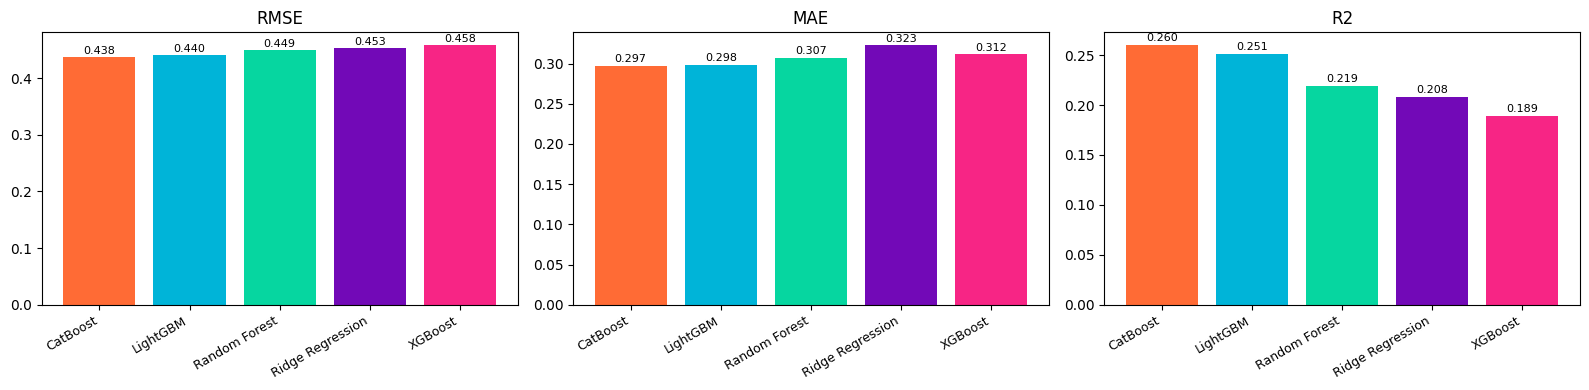

In [25]:
# visualización de las métricas por modelo
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colores = ['#FF6B35', '#00B4D8', '#06D6A0', '#7209B7', '#F72585']
nombres = resultados['Modelo'].tolist()

for ax, metrica in zip(axes, ['RMSE', 'MAE', 'R2']):
    valores = resultados[metrica].tolist()
    barras  = ax.bar(nombres, valores, color=colores)
    ax.set_title(metrica)
    ax.set_xticklabels(nombres, rotation=30, ha='right', fontsize=9)
    for bar, val in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 7.7 Selección del modelo ganador

**CatBoost** obtiene el mejor resultado en las tres métricas: menor RMSE (0.4375), menor MAE (0.2974) y mayor R² (0.2598).

Esto significa que en promedio el modelo se equivoca en **0.30 millones de unidades** (MAE) al predecir las ventas de un juego. En un rango de predicción de 0 a 2.64M, ese es un error razonable para el contexto.

El R² de 0.26 indica que el modelo explica el 26% de la variabilidad en las ventas. Puede parecer bajo, pero refleja honestamente la dificultad del problema: la mayoría de los factores que determinan el éxito de un videojuego (marketing, boca a boca, tendencias culturales, decisiones del publisher) no están capturados en estas variables. El 26% de señal estadística sigue siendo información valiosa para orientar decisiones de inversión.

**Limitación documentada:** el modelo predice de forma confiable en el rango 0 a 2.64M de ventas. Para juegos con potencial de superar ese umbral, la predicción será una subestimación.

---
## 8. Análisis del modelo ganador

### 8.1 Feature importance

**Feature importance** indica cuánto contribuyó cada variable a las predicciones del modelo. Es útil para entender qué factores son los más determinantes según los datos históricos y para comunicar los resultados al equipo de negocio.

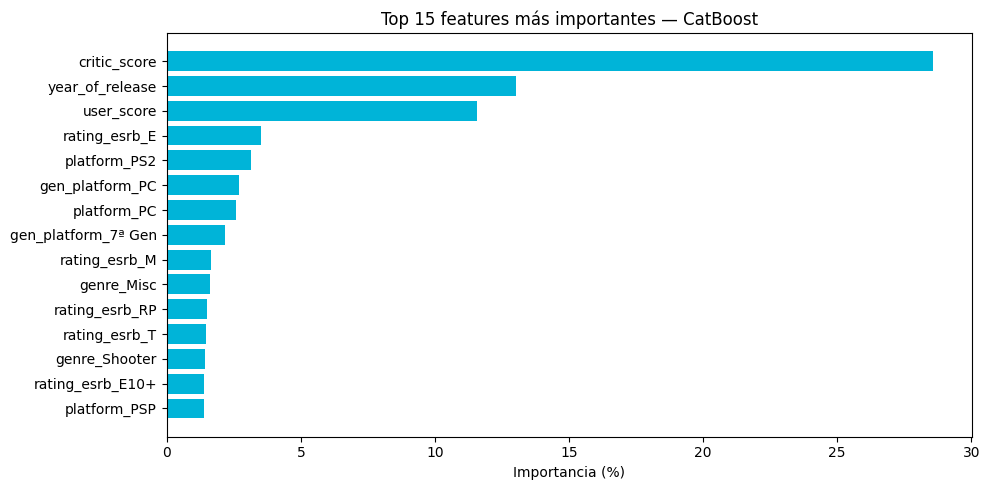

Top 10 features:
critic_score           28.58
year_of_release        13.02
user_score             11.58
rating_esrb_E           3.50
platform_PS2            3.13
gen_platform_PC         2.69
platform_PC             2.58
gen_platform_7ª Gen     2.16
rating_esrb_M           1.63
genre_Misc              1.60
dtype: float64


In [26]:
importancias = pd.Series(
    modelo_catboost.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top15 = importancias.head(15)

plt.figure(figsize=(10, 5))
bars = plt.barh(top15.index[::-1], top15.values[::-1], color='#00B4D8')
plt.xlabel('Importancia (%)')
plt.title('Top 15 features más importantes — CatBoost')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(top15.head(10).round(2))

**Interpretación de negocio:**

- `critic_score` es la variable más influyente por amplio margen. Esto sugiere que invertir en calidad de producto y en obtener buenas reseñas tiene más impacto en ventas que la elección de plataforma o género.
- `year_of_release` y `user_score` son las siguientes más importantes, lo que refleja que la época del lanzamiento y la recepción de la comunidad también importan.
- Las variables de plataforma y género tienen impacto moderado pero consistente.

### 8.2 Ejemplo de predicción manual

Probamos el modelo con un juego ficticio para ver qué predice. Este es exactamente el flujo que usará la API cuando reciba una solicitud.

In [27]:
# definir un juego ficticio de prueba
juego_nuevo = pd.DataFrame([{
    'platform':                   'PS4',
    'genre':                      'Action',
    'rating_esrb':                'M',
    'gen_platform':               '8ª Gen',
    'classification_user_score':  'Excellent',
    'year_of_release':            2015,
    'critic_score':               85.0,
    'user_score':                 8.5
}])

# aplicar el mismo encoder entrenado
juego_cat_enc = encoder.transform(juego_nuevo[COLUMNAS_CATEGORICAS])
juego_cat_df  = pd.DataFrame(juego_cat_enc, columns=encoder.get_feature_names_out(COLUMNAS_CATEGORICAS))
juego_X       = pd.concat([juego_nuevo[COLUMNAS_NUMERICAS].reset_index(drop=True), juego_cat_df], axis=1)

prediccion = modelo_catboost.predict(juego_X)[0]

print('Juego de prueba:')
print(f'  Plataforma:   PS4')
print(f'  Género:       Action')
print(f'  ESRB:         M (Mature)')
print(f'  Critic Score: 85')
print(f'  User Score:   8.5')
print(f'  Año:          2015')
print()
print(f'  Prediccion de ventas: {prediccion:.2f}M de unidades')

Juego de prueba:
  Plataforma:   PS4
  Género:       Action
  ESRB:         M (Mature)
  Critic Score: 85
  User Score:   8.5
  Año:          2015

  Prediccion de ventas: 0.92M de unidades


---
## 9. Exportar los archivos para producción

### 9.1 ¿Qué es serialización? ¿Pickle vs joblib?

Cuando el modelo termina de entrenarse, existe solo en la memoria RAM de la computadora. Si cerramos Python, se pierde. Para guardarlo en disco necesitamos **serialización**: convertir el objeto Python a una secuencia de bytes que se pueda escribir como archivo.

Python incluye de forma nativa una librería llamada **pickle** que hace exactamente eso. Sin embargo, los modelos de ML contienen arrays de numpy de gran tamaño, y pickle no está optimizado para eso.

**joblib** es la alternativa estándar en el ecosistema de scikit-learn: usa compresión eficiente para arrays numéricos grandes, es más rápido que pickle para modelos de ML, y es la forma recomendada por la documentación de scikit-learn.

### 9.2 ¿Por qué guardar dos archivos y no uno?

El modelo solo no es suficiente para producción. El **encoder** es tan importante como el modelo porque:

1. La API va a recibir texto: `{"genre": "Action", "platform": "PS4", ...}`
2. El modelo solo entiende números: espera una matriz de 58 columnas con ceros y unos
3. El encoder transforma el texto a esa matriz en el formato exacto que el modelo vio durante el entrenamiento

Sin el encoder, la API recibe la solicitud pero no puede preparar los datos para el modelo. Son dos piezas de un mismo mecanismo: se guardan juntas y se cargan juntas.

In [28]:
# crear la carpeta models si no existe
MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

# rutas de los archivos de salida
MODEL_PATH   = os.path.join(MODELS_DIR, 'catboost_regressor.joblib')
ENCODER_PATH = os.path.join(MODELS_DIR, 'onehot_encoder.joblib')

# joblib.dump: serializa el objeto y lo guarda en el path indicado
joblib.dump(modelo_catboost, MODEL_PATH)
joblib.dump(encoder,         ENCODER_PATH)

print(f'Modelo guardado en:  {MODEL_PATH}')
print(f'Encoder guardado en: {ENCODER_PATH}')

Modelo guardado en:  models\catboost_regressor.joblib
Encoder guardado en: models\onehot_encoder.joblib


### 9.3 Verificación: cargar y predecir

Antes de dar por finalizada la sesión, verificamos que los archivos se carguen correctamente y produzcan la misma predicción que el modelo en memoria.

In [29]:
# cargar los archivos desde disco
modelo_cargado  = joblib.load(MODEL_PATH)
encoder_cargado = joblib.load(ENCODER_PATH)

# repetir la predicción del juego ficticio con los objetos cargados
juego_cat_enc_v  = encoder_cargado.transform(juego_nuevo[COLUMNAS_CATEGORICAS])
juego_cat_df_v   = pd.DataFrame(juego_cat_enc_v, columns=encoder_cargado.get_feature_names_out(COLUMNAS_CATEGORICAS))
juego_X_v        = pd.concat([juego_nuevo[COLUMNAS_NUMERICAS].reset_index(drop=True), juego_cat_df_v], axis=1)

prediccion_verificacion = modelo_cargado.predict(juego_X_v)[0]

print(f'Prediccion con modelo en memoria: {prediccion:.4f}M')
print(f'Prediccion con modelo desde disco: {prediccion_verificacion:.4f}M')
print()
if abs(prediccion - prediccion_verificacion) < 0.0001:
    print('Verificacion exitosa: los resultados son identicos.')
else:
    print('ADVERTENCIA: hay diferencia entre los resultados.')

Prediccion con modelo en memoria: 0.9158M
Prediccion con modelo desde disco: 0.9158M

Verificacion exitosa: los resultados son identicos.


---
## 10. Conclusiones

### Decisiones tomadas y su justificación

**Variables:** se usaron las 8 features disponibles antes del lanzamiento. Las ventas regionales se descartaron por data leakage. Reducir a solo las 3 variables numéricas más correlacionadas empeoró los resultados (R² de 0.13 a 0.03), confirmando que las variables categóricas aportan información real al modelo.

**Outliers:** se eliminó el top 5% de ventas (corte en 2.64M), reduciendo el skewness de 17.07 a 1.89. Esta decisión redujo el RMSE de 2.30 a 0.44, una mejora de 5 veces. El `games_clean.csv` original no fue modificado.

**Modelo:** se evaluaron 5 modelos. CatBoost obtuvo el mejor desempeño en las tres métricas (RMSE: 0.4375, MAE: 0.2974, R²: 0.2598) y fue seleccionado para producción.

### Lo que aprendimos sobre los datos de videojuegos

La variable más influyente en las ventas es el `critic_score`, seguida del año de lanzamiento y el `user_score`. La plataforma y el género tienen impacto moderado. El 74% de la variabilidad en las ventas no es explicada por estas variables, lo que confirma que el éxito en la industria del videojuego depende en gran parte de factores cualitativos y contextuales que no se pueden capturar en un dataset histórico.

### Qué sigue: la sesión del lunes

Los dos archivos generados en esta sesión (`catboost_regressor.joblib` y `onehot_encoder.joblib`) son la salida que conecta este notebook con el resto del sistema. El lunes vamos a extraer esta lógica a scripts `.py` limpios para producción, y el martes construiremos la API con FastAPI que los carga y sirve predicciones en tiempo real.

---
## 11. Referencias

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785-794. https://doi.org/10.1145/2939672.2939785

Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T. Y. (2017). LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems*, 30. https://proceedings.neurips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html

Prokhorenkova, L., Gusev, G., Vorobev, A., Dorogush, A. V., & Gulin, A. (2018). CatBoost: Unbiased boosting with categorical features. *Advances in Neural Information Processing Systems*, 31. https://proceedings.neurips.cc/paper/2018/hash/14491b756b3a51daac41c24863285549-Abstract.html

Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32. https://doi.org/10.1023/A:1010933404324

Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. *Technometrics*, 12(1), 55-67. https://doi.org/10.1080/00401706.1970.10488634

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830. https://jmlr.org/papers/v12/pedregosa11a.html

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61. https://doi.org/10.25080/Majora-92bf1922-00a

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., & Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, 585(7825), 357-362. https://doi.org/10.1038/s41586-020-2649-2